In [1]:
%pip install scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv(r'D:\fsds\projects\datasets\car-mpg.csv')
df.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino


In [3]:
df=df.drop(['car_name'], axis=1)
df['origin']=df['origin'].replace({1:"america", 2:"europe", 3:"asia"})
df=pd.get_dummies(df, columns=['origin'], dtype=int)
df=df.replace('?', np.nan)
df

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140,3449,10.5,70,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,1,0,0
394,44.0,4,97.0,52,2130,24.6,82,1,0,0,1
395,32.0,4,135.0,84,2295,11.6,82,1,1,0,0
396,28.0,4,120.0,79,2625,18.6,82,1,1,0,0


In [4]:
df=df.apply(pd.to_numeric, errors='ignore')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols]=df[numeric_cols].apply(lambda x: x.fillna(x.median()))

df.head()

C:\Users\bhara\AppData\Local\Temp\ipykernel_10048\1946947793.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df=df.apply(pd.to_numeric, errors='ignore')


,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130.0,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,0,1,0,0


# Building Model

In [5]:
x = df.drop(['mpg'], axis=1)
y = df['mpg']

# Data Preprocessing

In [6]:
from sklearn import preprocessing

x_s = preprocessing.scale(x)
x_s = pd.DataFrame(x_s, columns=x.columns)

y_s = preprocessing.scale(y)
y_s = pd.DataFrame(y_s, columns=y.columns)

AttributeError: 'Series' object has no attribute 'columns'

In [7]:
x_s

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
...,...,...,...,...,...,...,...,...,...,...
393,-0.856321,-0.513026,-0.479482,-0.213324,0.011586,1.621983,0.941412,0.773559,-0.497643,-0.461968
394,-0.856321,-0.925936,-1.370127,-0.993671,3.279296,1.621983,0.941412,-1.292726,-0.497643,2.164651
395,-0.856321,-0.561039,-0.531873,-0.798585,-1.440730,1.621983,0.941412,0.773559,-0.497643,-0.461968
396,-0.856321,-0.705077,-0.662850,-0.408411,1.100822,1.621983,0.941412,0.773559,-0.497643,-0.461968


In [8]:
y_s

array([-7.06438701e-01, -1.09075062e+00, -7.06438701e-01, -9.62646649e-01,
       -8.34542675e-01, -1.09075062e+00, -1.21885460e+00, -1.21885460e+00,
       -1.21885460e+00, -1.09075062e+00, -1.09075062e+00, -1.21885460e+00,
       -1.09075062e+00, -1.21885460e+00,  6.21851453e-02, -1.94022803e-01,
       -7.06438701e-01, -3.22126778e-01,  4.46497068e-01,  3.18393094e-01,
        1.90289120e-01,  6.21851453e-02,  1.90289120e-01,  3.18393094e-01,
       -3.22126778e-01, -1.73127050e+00, -1.73127050e+00, -1.60316652e+00,
       -1.85937447e+00,  4.46497068e-01,  5.74601043e-01,  1.90289120e-01,
        1.90289120e-01, -5.78334726e-01, -9.62646649e-01, -8.34542675e-01,
       -5.78334726e-01, -7.06438701e-01, -1.21885460e+00, -1.21885460e+00,
       -1.21885460e+00, -1.21885460e+00, -1.47506255e+00, -1.34695857e+00,
       -1.34695857e+00, -7.06438701e-01, -1.94022803e-01, -5.78334726e-01,
       -7.06438701e-01, -6.59188290e-02,  5.74601043e-01,  8.30808991e-01,
        8.30808991e-01,  

# Splitting data into train and test data

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
x_train.shape

(318, 10)

# Building Linear Regression Model

In [10]:
regression_model = LinearRegression()
regression_model.fit(x_train, y_train)

for idx, col_name in enumerate(x_train.columns):
    print(f"Coefficient for {col_name} is: {regression_model.coef_[idx]}")
intercept = regression_model.intercept_
print(f'The intercept is: {intercept}')


Coefficient for cyl is: 1.132132901692931
Coefficient for disp is: 0.021870916664800812
Coefficient for hp is: -0.0369743503962915
Coefficient for wt is: -0.006161226821177595
Coefficient for acc is: 0.18528379196930178
Coefficient for yr is: 0.735971051909314
Coefficient for car_type is: 5.222818504062046
Coefficient for origin_america is: -1.5337484062982116
Coefficient for origin_asia is: 1.1429070547072941
Coefficient for origin_europe is: 0.3908413515909156
The intercept is: -25.804524189791742


# Building Ridge Regression

In [11]:
ridge_model = Ridge(alpha=0.4)
ridge_model.fit(x_train, y_train)

print(f'ridge intercept: {ridge_model.coef_}')

ridge intercept: [ 1.0745122   0.02197319 -0.03635311 -0.00617876  0.18529325  0.73685277
  5.03900692 -1.53771689  1.13791133  0.39980556]


# Building Lasso Regression

In [12]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train, y_train)

print(f'lasso intercept: {lasso_model.coef_}')

lasso intercept: [ 0.          0.02297791 -0.02592527 -0.00641316  0.14984857  0.74506564
  2.04547367 -1.83928628  0.0771301  -0.        ]


# Score Comparison

In [13]:
print(regression_model.score(x_train, y_train))
print(regression_model.score(x_test, y_test))

print('***************************************************')
#ridge
print(ridge_model.score(x_train, y_train))
print(ridge_model.score(x_test, y_test))

print('***************************************************')
#lasso
print(lasso_model.score(x_train, y_train))
print(lasso_model.score(x_test, y_test))

0.8373422857977738
0.8474768646673945
***************************************************
0.8373217642150055
0.8473212982285181
***************************************************
0.8293310961823916
0.8431064583301076


# Model Parameter Tuning

- Since r^2 always changes when more attributes are added, even if the attributes have no effect  on the predicted variable.
- hence we use adjusted r^2 as it removes the statistical chance that improves r^2
- adjusted r^2 = r^2 - fluke


In [14]:
data_train_test = pd.concat([x_train, y_train], axis=1)
data_train_test.head()

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe,mpg
64,8,318.0,150.0,4135,13.5,72,0,1,0,0,15.0
55,4,97.0,60.0,1834,19.0,71,1,0,0,1,27.0
317,4,97.0,78.0,2188,15.8,80,1,0,0,1,34.3
102,4,97.0,46.0,1950,21.0,73,1,0,0,1,26.0
358,4,120.0,74.0,2635,18.3,81,1,0,1,0,31.6


In [15]:
import statsmodels.formula.api as smf 
ols1 = smf.ols(formula='mpg ~ cyl+disp+hp+wt+acc+yr+car_type+origin_america+origin_asia+origin_europe', data=data_train_test).fit()
print(ols1.params)

Intercept        -19.353393
cyl                1.132133
disp               0.021871
hp                -0.036974
wt                -0.006161
acc                0.185284
yr                 0.735971
car_type           5.222819
origin_america    -7.984879
origin_asia       -5.308224
origin_europe     -6.060290
dtype: float64


In [16]:
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     176.2
Date:                Fri, 25 Jul 2025   Prob (F-statistic):          7.60e-116
Time:                        15:50:02   Log-Likelihood:                -814.21
No. Observations:                 318   AIC:                             1648.
Df Residuals:                     308   BIC:                             1686.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -19.3534      3.867     -5.

##### Sum of Squared Errors to predict the value of y for test cases and subtracting from actual y for the test case

In [17]:
mse = np.mean(regression_model.predict(x_test) - y_test) ** 2

# RMSE is standard deviation i.e. average variance between predicted and actual values
import math
rmse=math.sqrt(mse)
print(f'RMSE: {rmse}')

RMSE: 0.6993068446081091


<Axes: xlabel='acc', ylabel='mpg'>

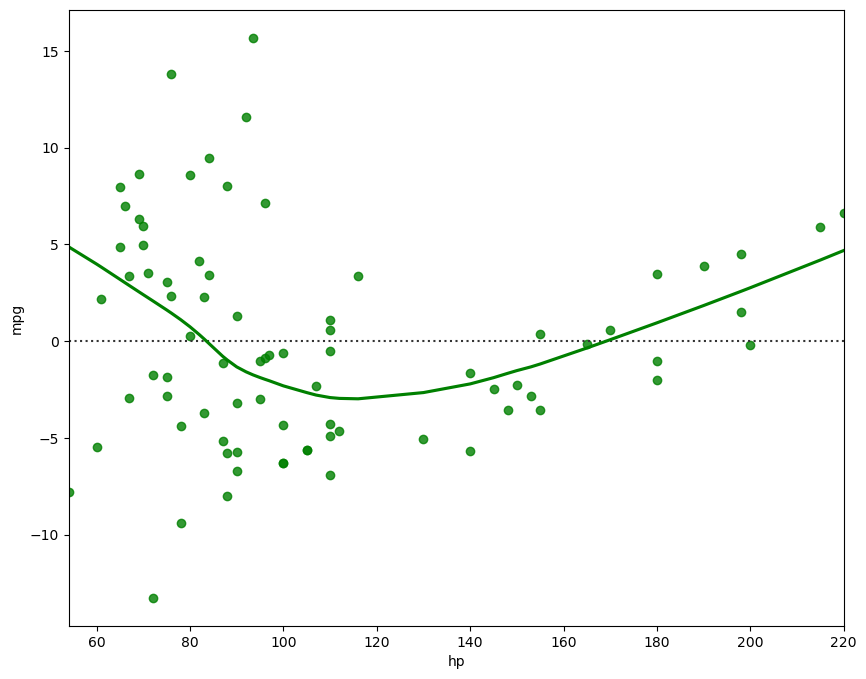

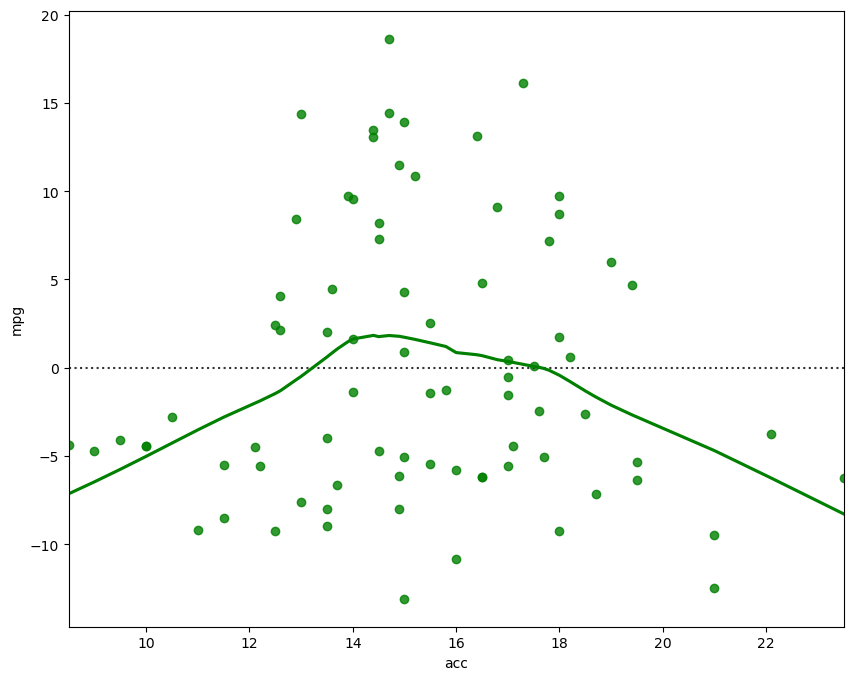

In [19]:
fig = plt.figure(figsize=(10,8))
sns.residplot(x= x_test['hp'], y= y_test, color='green', lowess=True )


fig = plt.figure(figsize=(10,8))
sns.residplot(x= x_test['acc'], y= y_test, color='green', lowess=True )

In [22]:
y_pred = regression_model.predict(x_test)

plt.scatter(y_test['mpg'], y_pred)

KeyError: 'mpg'